In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [13]:
df = pd.read_csv("../data/18_열처리.csv")

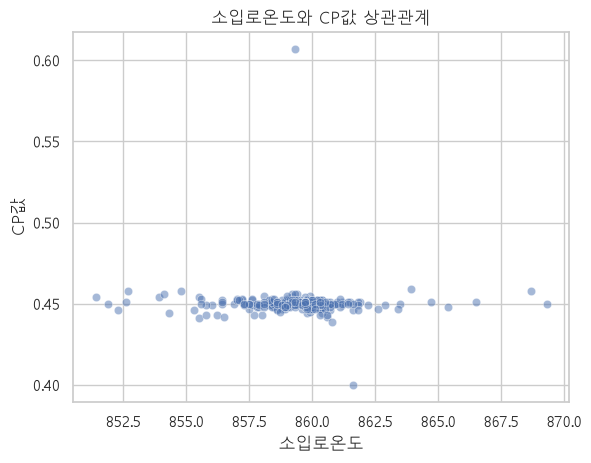

In [14]:
# 간단한 산점도 그리기
sns.scatterplot(data=df, x='소입로온도', y='CP값', alpha=0.5)
plt.title('소입로온도와 CP값 상관관계')
plt.show()

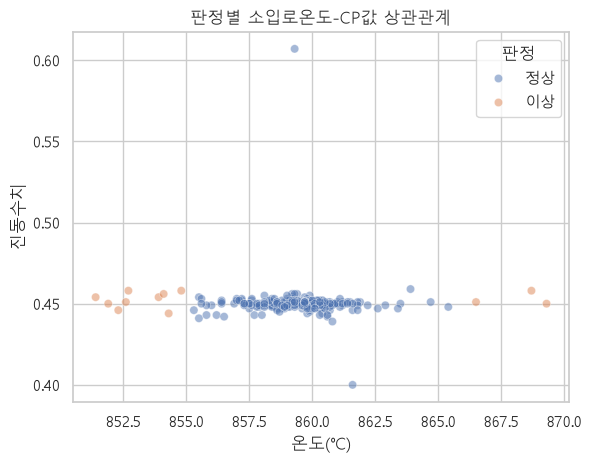

In [15]:
# hue로 그룹 구분해 패턴찾기
sns.scatterplot(data=df, x='소입로온도', y='CP값', hue='판정', alpha=0.5)
plt.title('판정별 소입로온도-CP값 상관관계')
plt.xlabel('온도(℃)')
plt.ylabel('진동수치')
plt.show()

In [16]:
# 상관관계: -1 ~ 1
corr = df.corr(numeric_only=True)
print(corr.round(2))
# 소입로온도  제어출력  건조출력   세정기   CP값
# 소입로온도   1.00 -0.74 -0.01  0.03 -0.03
# 제어출력   -0.74  1.00  0.09 -0.02  0.01
# 건조출력   -0.01  0.09  1.00 -0.05 -0.10
# 세정기     0.03 -0.02 -0.05  1.00 -0.04
# CP값    -0.03  0.01 -0.10 -0.04  1.00
print("소입로온도-제어출력 상관:", df["소입로온도"].corr(df["제어출력"]).round(2))
# 소입로온도-제어출력 상관: -0.74

       소입로온도  제어출력  건조출력   세정기   CP값
소입로온도   1.00 -0.74 -0.01  0.03 -0.03
제어출력   -0.74  1.00  0.09 -0.02  0.01
건조출력   -0.01  0.09  1.00 -0.05 -0.10
세정기     0.03 -0.02 -0.05  1.00 -0.04
CP값    -0.03  0.01 -0.10 -0.04  1.00
소입로온도-제어출력 상관: -0.74


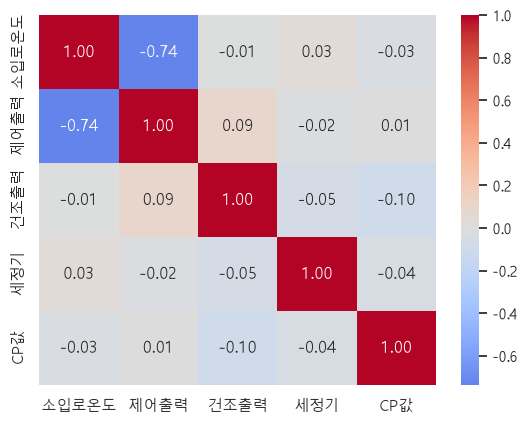

In [17]:
# 간단한 상관관계 히트맵
sns.heatmap(data=corr,annot=True, fmt=".2f", cmap="coolwarm", center=0)
# annot=True로 숫자 보이게
# fmt=".2f" 으로 소수점 2째 자리까지 표시
# cmap="coolwarm" 으로 색깔 변경  # 더 다양한 색상은 seaborn사이트에서 확인
# center=0 는 0을 기준으로 음의 상관과 양의 상관을 색으로 명확하게 구분하기 위함
plt.show()

<Axes: xlabel='소입로온도', ylabel='세정기'>

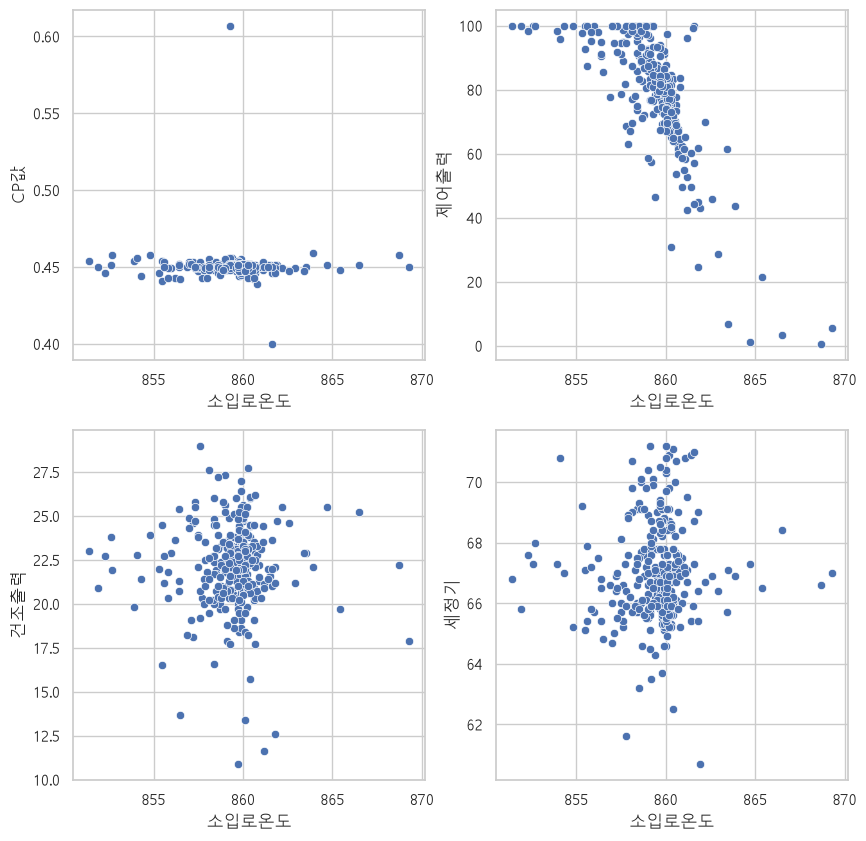

In [18]:
# 간단한 subplot 활용

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
sns.scatterplot(data=df, x="소입로온도", y="CP값", ax=axs[0, 0])
sns.scatterplot(data=df, x="소입로온도", y="제어출력", ax=axs[0, 1])
sns.scatterplot(data=df, x="소입로온도", y="건조출력", ax=axs[1, 0])
sns.scatterplot(data=df, x="소입로온도", y="세정기", ax=axs[1, 1])